# 02 — Analisis Dataset GCD

Notebook ini digunakan untuk melakukan eksplorasi dan validasi awal
TJNU Ground-based Cloud Dataset (GCD) sebelum tahap preprocessing
dan pelatihan model klasifikasi citra awan.

Analisis meliputi:

- Struktur dataset
- Jumlah citra
- Distribusi kelas
- Distribusi train dan test
- Resolusi citra
- Format warna
- File rusak
- Duplikasi citra
- Potensi data leakage
- Visualisasi sampel citra
- Statistik intensitas citra
- Analisis RGB
- Kesiapan dataset untuk training

In [3]:
import sys
import os
from pathlib import Path

print("Python executable :", sys.executable)
print("Python version    :", sys.version)
print("Working directory :", Path.cwd())

Python executable : c:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\.venv\Scripts\python.exe
Python version    : 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Working directory : c:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\notebooks


In [4]:
from pathlib import Path
from collections import Counter
import hashlib
import random
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageStat
from tqdm.auto import tqdm
from IPython.display import display

print("Library berhasil dimuat.")

Library berhasil dimuat.


In [6]:
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATASET_ROOT = PROJECT_ROOT / "dataset"

print("Current directory :", CURRENT_DIR)
print("Project root      :", PROJECT_ROOT)
print("Dataset root      :", DATASET_ROOT)
print("Dataset tersedia  :", DATASET_ROOT.exists())

Current directory : C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\notebooks
Project root      : C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification
Dataset root      : C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset
Dataset tersedia  : True


In [7]:
if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"Folder dataset tidak ditemukan:\n{DATASET_ROOT}"
    )

print("Folder dataset ditemukan.")

Folder dataset ditemukan.


In [8]:
def show_tree(path, max_depth=3):
    path = Path(path)

    print(path.name + "/")

    for item in sorted(path.rglob("*")):
        try:
            relative = item.relative_to(path)
        except ValueError:
            continue

        depth = len(relative.parts)

        if depth > max_depth:
            continue

        indent = "    " * depth

        if item.is_dir():
            print(f"{indent}{item.name}/")


show_tree(DATASET_ROOT, max_depth=4)

dataset/
    processed/
    raw/
        GCD/
            GCD/
                test/
                train/
    source/
    test/
    train/
    val/


In [10]:
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
}

print("Format citra yang akan dibaca:")
print(IMAGE_EXTENSIONS)

Format citra yang akan dibaca:
{'.bmp', '.jpg', '.png', '.webp', '.jpeg'}


In [11]:
image_paths = [
    path
    for path in DATASET_ROOT.rglob("*")
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
]

print(f"Total file citra ditemukan: {len(image_paths):,}")

Total file citra ditemukan: 19,000


In [12]:
CLASS_NAMES = {
    "1": "Cumulus",
    "2": "Altocumulus / Cirrocumulus",
    "3": "Cirrus / Cirrostratus",
    "4": "Clear Sky",
    "5": "Stratocumulus / Stratus / Altostratus",
    "6": "Cumulonimbus / Nimbostratus",
    "7": "Mixed Cloud",
}

class_table = pd.DataFrame(
    {
        "class_id": list(CLASS_NAMES.keys()),
        "class_name": list(CLASS_NAMES.values()),
    }
)

display(class_table)

,class_id,class_name
0,1,Cumulus
1,2,Altocumulus / Cirrocumulus
2,3,Cirrus / Cirrostratus
3,4,Clear Sky
4,5,Stratocumulus / Stratus / Altostratus
5,6,Cumulonimbus / Nimbostratus
6,7,Mixed Cloud


In [13]:
SPLIT_MAPPING = {
    "train": "train",
    "training": "train",
    "test": "test",
    "testing": "test",
    "val": "validation",
    "valid": "validation",
    "validation": "validation",
}


def detect_split(path):
    parts = [part.lower() for part in path.parts]

    for part in parts:
        if part in SPLIT_MAPPING:
            return SPLIT_MAPPING[part]

    return "unknown"

In [17]:
SPLIT_MAPPING = {
    "train": "train",
    "training": "train",
    "test": "test",
    "testing": "test",
    "val": "validation",
    "valid": "validation",
    "validation": "validation",
}


def detect_split(path):
    parts = [part.lower() for part in path.parts]

    for part in parts:
        if part in SPLIT_MAPPING:
            return SPLIT_MAPPING[part]

    return "unknown"

In [19]:
def detect_class(path):
    parts = list(path.parts)

    for part in reversed(parts):
        cleaned = part.strip()

        if cleaned in CLASS_NAMES:
            return cleaned

    return path.parent.name

In [20]:
records = []

for path in image_paths:
    relative_path = path.relative_to(DATASET_ROOT)

    class_id = detect_class(relative_path)
    split = detect_split(relative_path)

    records.append({
        "filename": path.name,
        "relative_path": str(relative_path),
        "absolute_path": str(path),
        "split": split,
        "class_id": class_id,
        "class_name": CLASS_NAMES.get(
            str(class_id),
            str(class_id)
        ),
        "extension": path.suffix.lower(),
        "file_size_bytes": path.stat().st_size,
    })


df = pd.DataFrame(records)

print("Jumlah data :", len(df))

display(df.head(10))

Jumlah data : 19000


,filename,relative_path,absolute_path,split,class_id,class_name,extension,file_size_bytes
0,1_cumulus_000776.jpg,raw\GCD\GCD\test\1_cumulus\1_cumulus_000776.jpg,C:\Users\jardm\Documents\n8n-logsiswaparalayan...,test,1_cumulus,1_cumulus,.jpg,10128
1,1_cumulus_000777.jpg,raw\GCD\GCD\test\1_cumulus\1_cumulus_000777.jpg,C:\Users\jardm\Documents\n8n-logsiswaparalayan...,test,1_cumulus,1_cumulus,.jpg,11222
2,1_cumulus_000778.jpg,raw\GCD\GCD\test\1_cumulus\1_cumulus_000778.jpg,C:\Users\jardm\Documents\n8n-logsiswaparalayan...,test,1_cumulus,1_cumulus,.jpg,11258
3,1_cumulus_000779.jpg,raw\GCD\GCD\test\1_cumulus\1_cumulus_000779.jpg,C:\Users\jardm\Documents\n8n-logsiswaparalayan...,test,1_cumulus,1_cumulus,.jpg,13588
4,1_cumulus_000780.jpg,raw\GCD\GCD\test\1_cumulus\1_cumulus_000780.jpg,C:\Users\jardm\Documents\n8n-logsiswaparalayan...,test,1_cumulus,1_cumulus,.jpg,10656
5,1_cumulus_000781.jpg,raw\GCD\GCD\test\1_cumulus\1_cumulus_000781.jpg,C:\Users\jardm\Documents\n8n-logsiswaparalayan...,test,1_cumulus,1_cumulus,.jpg,7421
6,1_cumulus_000782.jpg,raw\GCD\GCD\test\1_cumulus\1_cumulus_000782.jpg,C:\Users\jardm\Documents\n8n-logsiswaparalayan...,test,1_cumulus,1_cumulus,.jpg,10108
7,1_cumulus_000783.jpg,raw\GCD\GCD\test\1_cumulus\1_cumulus_000783.jpg,C:\Users\jardm\Documents\n8n-logsiswaparalayan...,test,1_cumulus,1_cumulus,.jpg,12407
8,1_cumulus_000784.jpg,raw\GCD\GCD\test\1_cumulus\1_cumulus_000784.jpg,C:\Users\jardm\Documents\n8n-logsiswaparalayan...,test,1_cumulus,1_cumulus,.jpg,12965
9,1_cumulus_000785.jpg,raw\GCD\GCD\test\1_cumulus\1_cumulus_000785.jpg,C:\Users\jardm\Documents\n8n-logsiswaparalayan...,test,1_cumulus,1_cumulus,.jpg,15938


In [21]:
print("=" * 60)
print("RINGKASAN DATASET")
print("=" * 60)

print(f"Jumlah citra       : {len(df):,}")
print(f"Jumlah kelas       : {df['class_id'].nunique()}")
print(f"Jumlah split       : {df['split'].nunique()}")
print(f"Format file        : {sorted(df['extension'].unique())}")

print("\nSplit:")
print(df["split"].value_counts())

print("\nKelas:")
print(df["class_name"].value_counts())

RINGKASAN DATASET
Jumlah citra       : 19,000
Jumlah kelas       : 7
Jumlah split       : 2
Format file        : ['.jpg']

Split:
split
train    10000
test      9000
Name: count, dtype: int64

Kelas:
class_name
6_cumulonimbus     5764
4_clearsky         3739
5_stratocumulus    3636
3_cirrus           1906
1_cumulus          1525
2_altocumulus      1475
7_mixed             955
Name: count, dtype: int64


In [22]:
OFFICIAL_TOTAL = 19000
OFFICIAL_TRAIN = 10000
OFFICIAL_TEST = 9000

observed_total = len(df)

observed_train = (
    df["split"].eq("train").sum()
)

observed_test = (
    df["split"].eq("test").sum()
)

comparison = pd.DataFrame({
    "dataset": [
        "Total",
        "Train",
        "Test",
    ],
    "official": [
        OFFICIAL_TOTAL,
        OFFICIAL_TRAIN,
        OFFICIAL_TEST,
    ],
    "observed": [
        observed_total,
        observed_train,
        observed_test,
    ],
})

comparison["difference"] = (
    comparison["observed"]
    - comparison["official"]
)

display(comparison)

,dataset,official,observed,difference
0,Total,19000,19000,0
1,Train,10000,10000,0
2,Test,9000,9000,0


In [23]:
split_counts = (
    df["split"]
    .value_counts()
    .rename_axis("split")
    .reset_index(name="jumlah")
)

display(split_counts)

,split,jumlah
0,train,10000
1,test,9000


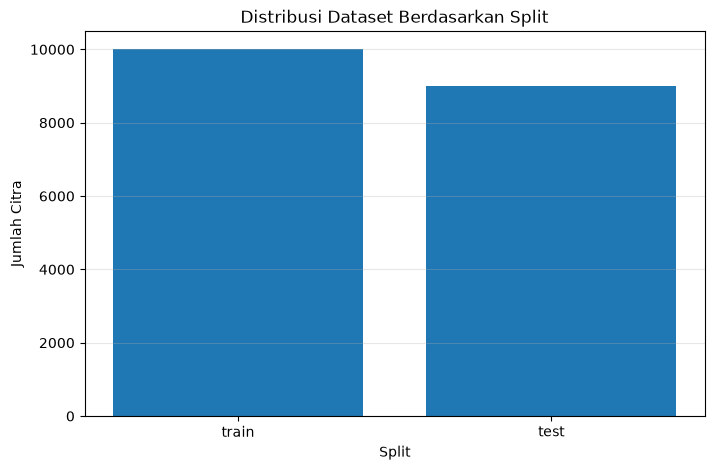

In [25]:
plt.figure(figsize=(8, 5))

plt.bar(
    split_counts["split"],
    split_counts["jumlah"]
)

plt.title("Distribusi Dataset Berdasarkan Split")
plt.xlabel("Split")
plt.ylabel("Jumlah Citra")

plt.grid(axis="y", alpha=0.3)
plt.show()

In [24]:
class_distribution = (
    df.groupby(["class_id", "class_name"])
    .size()
    .reset_index(name="jumlah")
    .sort_values("class_id")
)

display(class_distribution)

,class_id,class_name,jumlah
0,1_cumulus,1_cumulus,1525
1,2_altocumulus,2_altocumulus,1475
2,3_cirrus,3_cirrus,1906
3,4_clearsky,4_clearsky,3739
4,5_stratocumulus,5_stratocumulus,3636
5,6_cumulonimbus,6_cumulonimbus,5764
6,7_mixed,7_mixed,955


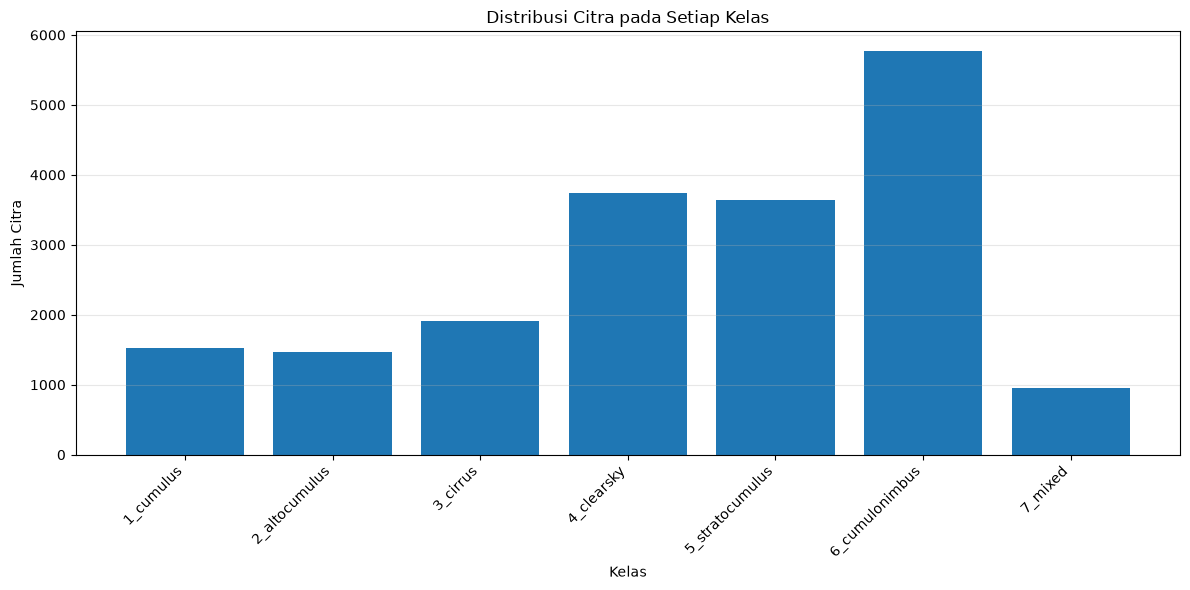

In [26]:
plt.figure(figsize=(12, 6))

plt.bar(
    class_distribution["class_name"],
    class_distribution["jumlah"]
)

plt.title("Distribusi Citra pada Setiap Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Citra")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [27]:
class_split_distribution = pd.crosstab(
    df["class_name"],
    df["split"]
)

display(class_split_distribution)

split,test,train
class_name,,
1_cumulus,750,775
2_altocumulus,750,725
3_cirrus,753,1153
4_clearsky,1589,2150
5_stratocumulus,1790,1846
6_cumulonimbus,2761,3003
7_mixed,607,348


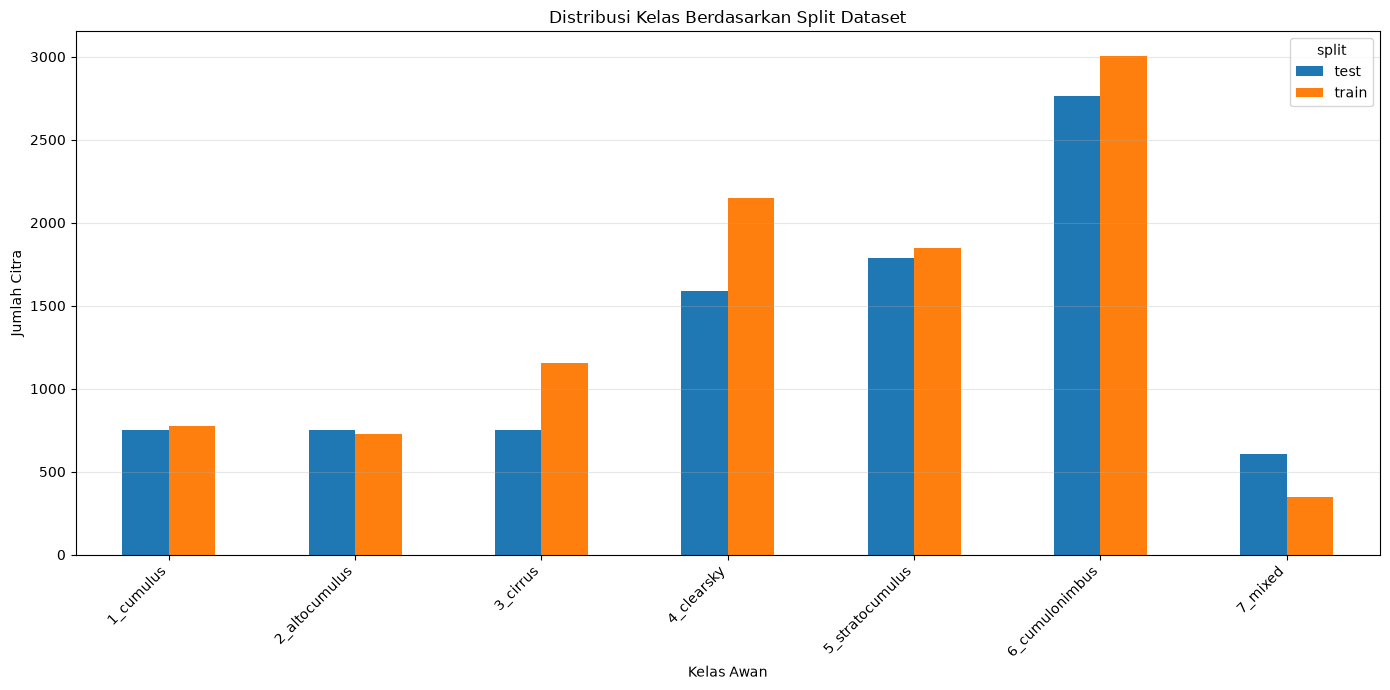

In [28]:
class_split_distribution.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Distribusi Kelas Berdasarkan Split Dataset")
plt.xlabel("Kelas Awan")
plt.ylabel("Jumlah Citra")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [29]:
class_counts = df["class_name"].value_counts()

largest_class = class_counts.max()
smallest_class = class_counts.min()

imbalance_ratio = (
    largest_class / smallest_class
    if smallest_class > 0
    else np.nan
)

print(f"Kelas terbesar : {largest_class:,}")
print(f"Kelas terkecil : {smallest_class:,}")
print(f"Imbalance ratio: {imbalance_ratio:.2f}")

Kelas terbesar : 5,764
Kelas terkecil : 955
Imbalance ratio: 6.04


In [30]:
format_distribution = (
    df["extension"]
    .value_counts()
    .rename_axis("extension")
    .reset_index(name="jumlah")
)

display(format_distribution)

,extension,jumlah
0,.jpg,19000


In [31]:
df["file_size_kb"] = (
    df["file_size_bytes"] / 1024
)

display(
    df["file_size_kb"].describe()
)

count    19000.000000
mean        10.218533
std          4.848470
min          4.907227
25%          7.014404
50%          8.447754
75%         11.690186
max         43.012695
Name: file_size_kb, dtype: float64

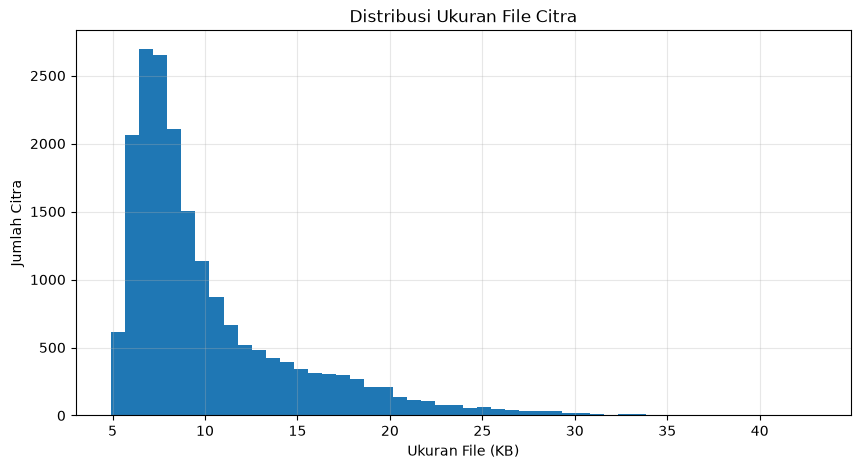

In [32]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["file_size_kb"],
    bins=50
)

plt.title("Distribusi Ukuran File Citra")
plt.xlabel("Ukuran File (KB)")
plt.ylabel("Jumlah Citra")

plt.grid(alpha=0.3)
plt.show()

In [33]:
image_metadata = []

for path in tqdm(
    image_paths,
    desc="Membaca metadata citra"
):
    try:
        with Image.open(path) as img:
            image_metadata.append({
                "absolute_path": str(path),
                "width": img.width,
                "height": img.height,
                "mode": img.mode,
                "format": img.format,
                "metadata_error": None,
            })

    except Exception as e:
        image_metadata.append({
            "absolute_path": str(path),
            "width": None,
            "height": None,
            "mode": None,
            "format": None,
            "metadata_error": str(e),
        })


metadata_df = pd.DataFrame(image_metadata)

df = df.merge(
    metadata_df,
    on="absolute_path",
    how="left"
)

print("Metadata selesai dibaca.")

Membaca metadata citra:   0%|          | 0/19000 [00:00<?, ?it/s]

Metadata selesai dibaca.


In [34]:
resolution_distribution = (
    df.groupby(["width", "height"])
    .size()
    .reset_index(name="jumlah")
    .sort_values(
        "jumlah",
        ascending=False
    )
)

display(
    resolution_distribution.head(20)
)

,width,height,jumlah
0,512,512,19000


In [35]:
unexpected_resolution = df[
    (df["width"] != 512)
    |
    (df["height"] != 512)
]

print(
    "Jumlah citra dengan resolusi "
    f"selain 512x512: {len(unexpected_resolution)}"
)

display(
    unexpected_resolution[
        [
            "relative_path",
            "width",
            "height",
            "class_name",
        ]
    ].head(20)
)

Jumlah citra dengan resolusi selain 512x512: 0


,relative_path,width,height,class_name


In [36]:
mode_distribution = (
    df["mode"]
    .value_counts(dropna=False)
    .rename_axis("mode")
    .reset_index(name="jumlah")
)

display(mode_distribution)

,mode,jumlah
0,RGB,19000


In [37]:
corrupted_files = []

for path in tqdm(
    image_paths,
    desc="Validasi file citra"
):
    try:
        with Image.open(path) as img:
            img.verify()

    except Exception as e:
        corrupted_files.append({
            "path": str(path),
            "error": str(e),
        })


corrupted_df = pd.DataFrame(
    corrupted_files
)

print(
    f"Jumlah file rusak: "
    f"{len(corrupted_files)}"
)

Validasi file citra:   0%|          | 0/19000 [00:00<?, ?it/s]

Jumlah file rusak: 0


In [38]:
display(corrupted_df)

""


In [39]:
duplicate_filename = df[
    df.duplicated(
        subset=["filename"],
        keep=False
    )
].sort_values("filename")

print(
    "Jumlah file dengan nama duplikat:",
    len(duplicate_filename)
)

display(
    duplicate_filename[
        [
            "filename",
            "split",
            "class_name",
            "relative_path",
        ]
    ].head(30)
)

Jumlah file dengan nama duplikat: 0


,filename,split,class_name,relative_path


In [40]:
def calculate_sha256(path):
    sha256 = hashlib.sha256()

    with open(path, "rb") as file:
        while True:
            chunk = file.read(1024 * 1024)

            if not chunk:
                break

            sha256.update(chunk)

    return sha256.hexdigest()

In [41]:
size_frequency = (
    df["file_size_bytes"]
    .value_counts()
)

duplicate_sizes = size_frequency[
    size_frequency > 1
].index

hash_candidates = df[
    df["file_size_bytes"].isin(
        duplicate_sizes
    )
].copy()

print(
    "File kandidat untuk pemeriksaan hash:",
    len(hash_candidates)
)

File kandidat untuk pemeriksaan hash: 14104


In [42]:
hash_candidates["sha256"] = [
    calculate_sha256(path)
    for path in tqdm(
        hash_candidates["absolute_path"],
        desc="Menghitung SHA-256"
    )
]

Menghitung SHA-256:   0%|          | 0/14104 [00:00<?, ?it/s]

In [43]:
duplicate_hashes = hash_candidates[
    hash_candidates.duplicated(
        subset=["sha256"],
        keep=False
    )
].sort_values("sha256")

print(
    "Jumlah file yang termasuk exact duplicate:",
    len(duplicate_hashes)
)

Jumlah file yang termasuk exact duplicate: 318


In [44]:
display(
    duplicate_hashes[
        [
            "filename",
            "split",
            "class_name",
            "relative_path",
            "sha256",
        ]
    ].head(50)
)

,filename,split,class_name,relative_path,sha256
13552,4_clearsky_001900.jpg,train,4_clearsky,raw\GCD\GCD\train\4_clearsky\4_clearsky_001900...,0429a3858bf7416033cdf3fcf4d1a10448e6296204f2e8...
3391,4_clearsky_003289.jpg,test,4_clearsky,raw\GCD\GCD\test\4_clearsky\4_clearsky_003289.jpg,0429a3858bf7416033cdf3fcf4d1a10448e6296204f2e8...
3412,4_clearsky_003310.jpg,test,4_clearsky,raw\GCD\GCD\test\4_clearsky\4_clearsky_003310.jpg,0436c94246ce5bd7828f0afa932ef40d268da6206ae3bb...
13570,4_clearsky_001918.jpg,train,4_clearsky,raw\GCD\GCD\train\4_clearsky\4_clearsky_001918...,0436c94246ce5bd7828f0afa932ef40d268da6206ae3bb...
13582,4_clearsky_001930.jpg,train,4_clearsky,raw\GCD\GCD\train\4_clearsky\4_clearsky_001930...,04e7033cb3b6714f0eb04bf8fa4b4d2fc586e5909c0c9f...
3426,4_clearsky_003324.jpg,test,4_clearsky,raw\GCD\GCD\test\4_clearsky\4_clearsky_003324.jpg,04e7033cb3b6714f0eb04bf8fa4b4d2fc586e5909c0c9f...
3528,4_clearsky_003426.jpg,test,4_clearsky,raw\GCD\GCD\test\4_clearsky\4_clearsky_003426.jpg,05fbc784db3ccb3d0ecb6bc158b3c0e1d537c85869748a...
12750,4_clearsky_001098.jpg,train,4_clearsky,raw\GCD\GCD\train\4_clearsky\4_clearsky_001098...,05fbc784db3ccb3d0ecb6bc158b3c0e1d537c85869748a...
12575,4_clearsky_000923.jpg,train,4_clearsky,raw\GCD\GCD\train\4_clearsky\4_clearsky_000923...,06af63d939fd1f6c65969e2912ec93232ba20c95415287...
3340,4_clearsky_003238.jpg,test,4_clearsky,raw\GCD\GCD\test\4_clearsky\4_clearsky_003238.jpg,06af63d939fd1f6c65969e2912ec93232ba20c95415287...


In [45]:
leakage_records = []

if not duplicate_hashes.empty:

    for sha256, group in duplicate_hashes.groupby(
        "sha256"
    ):
        splits = set(group["split"])

        if (
            "train" in splits
            and
            "test" in splits
        ):
            leakage_records.append(group)


if leakage_records:
    leakage_df = pd.concat(
        leakage_records,
        ignore_index=True
    )

else:
    leakage_df = pd.DataFrame()


print(
    "Jumlah file yang terindikasi "
    "leakage train-test:",
    len(leakage_df)
)

Jumlah file yang terindikasi leakage train-test: 312


In [73]:
if not leakage_df.empty:
    unique_leakage_hashes = leakage_df["sha256"].nunique()
    leakage_file_count = len(leakage_df)

    print("=" * 60)
    print("RINGKASAN TRAIN-TEST LEAKAGE")
    print("=" * 60)

    print(
        f"Jumlah file terlibat leakage : "
        f"{leakage_file_count:,}"
    )

    print(
        f"Jumlah hash unik leakage      : "
        f"{unique_leakage_hashes:,}"
    )

else:
    print("Tidak ditemukan train-test leakage.")

RINGKASAN TRAIN-TEST LEAKAGE
Jumlah file terlibat leakage : 312
Jumlah hash unik leakage      : 156


In [75]:
if not leakage_df.empty:

    leakage_group_summary = (
        leakage_df
        .groupby("sha256")
        .agg(
            jumlah_file=("filename", "count"),
            jumlah_split=("split", "nunique"),
            jumlah_kelas=("class_name", "nunique"),
        )
        .reset_index()
        .sort_values(
            "jumlah_file",
            ascending=False
        )
    )

    display(
        leakage_group_summary.head(20)
    )

,sha256,jumlah_file,jumlah_split,jumlah_kelas
0,0429a3858bf7416033cdf3fcf4d1a10448e6296204f2e8...,2,2,1
1,0436c94246ce5bd7828f0afa932ef40d268da6206ae3bb...,2,2,1
2,04e7033cb3b6714f0eb04bf8fa4b4d2fc586e5909c0c9f...,2,2,1
3,05fbc784db3ccb3d0ecb6bc158b3c0e1d537c85869748a...,2,2,1
4,06af63d939fd1f6c65969e2912ec93232ba20c95415287...,2,2,1
5,06c105451ae59ce405895925b1a7c89f6a1ef98720bc9c...,2,2,1
6,0e1cb07f8bd0ae9e3252ecacd7c8a5fddf7b423739ef77...,2,2,1
7,0edaa9fa326bf202ae886413f2841b98c09c79f0ae65a5...,2,2,1
8,0f0f7dd741afe7cf1d2e36847628a508dc7e0d4f1a7141...,2,2,1
9,0f77a2a49ed3bbcadc3df14e707d447a813efe098f570d...,2,2,1


In [76]:
if not leakage_df.empty:

    leakage_by_class = (
        leakage_df
        .groupby(
            [
                "class_id",
                "class_name",
                "split"
            ]
        )
        .size()
        .reset_index(
            name="jumlah_file"
        )
    )

    display(
        leakage_by_class
    )

,class_id,class_name,split,jumlah_file
0,4_clearsky,4_clearsky,test,155
1,4_clearsky,4_clearsky,train,155
2,7_mixed,7_mixed,test,1
3,7_mixed,7_mixed,train,1


In [77]:
if not leakage_df.empty:

    leakage_class_matrix = pd.pivot_table(
        leakage_df,
        index=[
            "class_id",
            "class_name"
        ],
        columns="split",
        values="filename",
        aggfunc="count",
        fill_value=0
    )

    display(
        leakage_class_matrix
    )

,split,test,train
class_id,class_name,,
4_clearsky,4_clearsky,155,155
7_mixed,7_mixed,1,1


In [78]:
if not duplicate_hashes.empty:

    duplicate_label_check = (
        duplicate_hashes
        .groupby("sha256")
        .agg(
            jumlah_file=("filename", "count"),
            jumlah_kelas=("class_name", "nunique"),
            kelas=(
                "class_name",
                lambda x: sorted(set(x))
            ),
        )
        .reset_index()
    )

    conflicting_labels = (
        duplicate_label_check[
            duplicate_label_check[
                "jumlah_kelas"
            ] > 1
        ]
    )

    print(
        "Duplicate dengan label berbeda:",
        len(conflicting_labels)
    )

    display(
        conflicting_labels.head(30)
    )

Duplicate dengan label berbeda: 0


,sha256,jumlah_file,jumlah_kelas,kelas


In [79]:
if not leakage_df.empty:

    leakage_pairs = (
        leakage_df[
            [
                "sha256",
                "split",
                "class_id",
                "class_name",
                "filename",
                "relative_path",
            ]
        ]
        .sort_values(
            [
                "sha256",
                "split"
            ]
        )
    )

    display(
        leakage_pairs.head(40)
    )

,sha256,split,class_id,class_name,filename,relative_path
1,0429a3858bf7416033cdf3fcf4d1a10448e6296204f2e8...,test,4_clearsky,4_clearsky,4_clearsky_003289.jpg,raw\GCD\GCD\test\4_clearsky\4_clearsky_003289.jpg
0,0429a3858bf7416033cdf3fcf4d1a10448e6296204f2e8...,train,4_clearsky,4_clearsky,4_clearsky_001900.jpg,raw\GCD\GCD\train\4_clearsky\4_clearsky_001900...
2,0436c94246ce5bd7828f0afa932ef40d268da6206ae3bb...,test,4_clearsky,4_clearsky,4_clearsky_003310.jpg,raw\GCD\GCD\test\4_clearsky\4_clearsky_003310.jpg
3,0436c94246ce5bd7828f0afa932ef40d268da6206ae3bb...,train,4_clearsky,4_clearsky,4_clearsky_001918.jpg,raw\GCD\GCD\train\4_clearsky\4_clearsky_001918...
5,04e7033cb3b6714f0eb04bf8fa4b4d2fc586e5909c0c9f...,test,4_clearsky,4_clearsky,4_clearsky_003324.jpg,raw\GCD\GCD\test\4_clearsky\4_clearsky_003324.jpg
4,04e7033cb3b6714f0eb04bf8fa4b4d2fc586e5909c0c9f...,train,4_clearsky,4_clearsky,4_clearsky_001930.jpg,raw\GCD\GCD\train\4_clearsky\4_clearsky_001930...
6,05fbc784db3ccb3d0ecb6bc158b3c0e1d537c85869748a...,test,4_clearsky,4_clearsky,4_clearsky_003426.jpg,raw\GCD\GCD\test\4_clearsky\4_clearsky_003426.jpg
7,05fbc784db3ccb3d0ecb6bc158b3c0e1d537c85869748a...,train,4_clearsky,4_clearsky,4_clearsky_001098.jpg,raw\GCD\GCD\train\4_clearsky\4_clearsky_001098...
9,06af63d939fd1f6c65969e2912ec93232ba20c95415287...,test,4_clearsky,4_clearsky,4_clearsky_003238.jpg,raw\GCD\GCD\test\4_clearsky\4_clearsky_003238.jpg
8,06af63d939fd1f6c65969e2912ec93232ba20c95415287...,train,4_clearsky,4_clearsky,4_clearsky_000923.jpg,raw\GCD\GCD\train\4_clearsky\4_clearsky_000923...


In [80]:
if not leakage_df.empty:

    example_hash = (
        leakage_df["sha256"]
        .iloc[0]
    )

    example_leakage = (
        leakage_df[
            leakage_df["sha256"]
            == example_hash
        ]
    )

    display(
        example_leakage[
            [
                "split",
                "class_id",
                "class_name",
                "filename",
                "relative_path",
            ]
        ]
    )

,split,class_id,class_name,filename,relative_path
0,train,4_clearsky,4_clearsky,4_clearsky_001900.jpg,raw\GCD\GCD\train\4_clearsky\4_clearsky_001900...
1,test,4_clearsky,4_clearsky,4_clearsky_003289.jpg,raw\GCD\GCD\test\4_clearsky\4_clearsky_003289.jpg


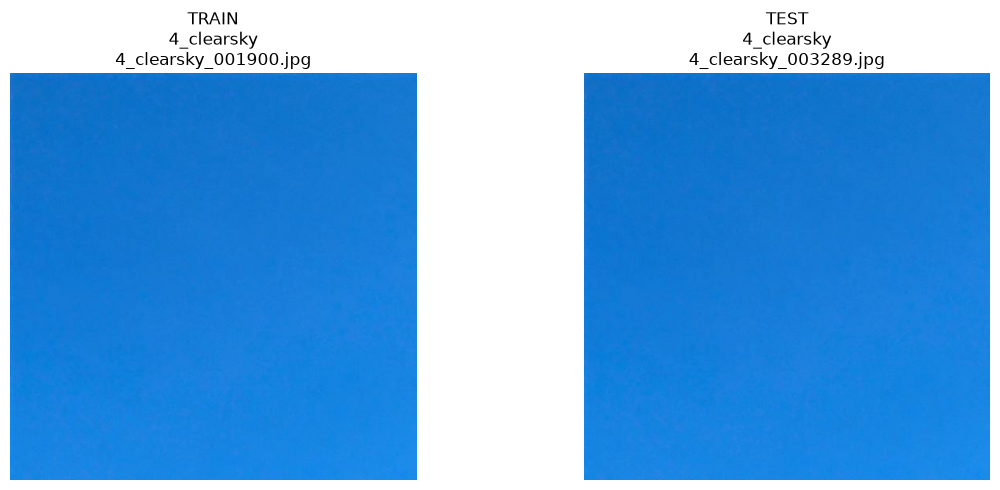

In [81]:
if not leakage_df.empty:

    example_group = (
        leakage_df[
            leakage_df["sha256"]
            == example_hash
        ]
    )

    n = len(example_group)

    plt.figure(
        figsize=(6 * n, 5)
    )

    for i, (_, row) in enumerate(
        example_group.iterrows(),
        start=1
    ):

        image = Image.open(
            row["absolute_path"]
        ).convert("RGB")

        plt.subplot(
            1,
            n,
            i
        )

        plt.imshow(image)

        plt.title(
            f"{row['split'].upper()}\n"
            f"{row['class_name']}\n"
            f"{row['filename']}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [82]:
def files_are_identical(path1, path2):
    with open(path1, "rb") as f1:
        data1 = f1.read()

    with open(path2, "rb") as f2:
        data2 = f2.read()

    return data1 == data2

In [83]:
if not leakage_df.empty:

    example_paths = (
        leakage_df[
            leakage_df["sha256"]
            == example_hash
        ]["absolute_path"]
        .tolist()
    )

    if len(example_paths) >= 2:

        identical = files_are_identical(
            example_paths[0],
            example_paths[1]
        )

        print(
            "File benar-benar identik:",
            identical
        )

File benar-benar identik: True


In [84]:
duplicate_groups = []

for sha256, group in duplicate_hashes.groupby(
    "sha256"
):

    splits = sorted(
        group["split"].unique()
    )

    if (
        "train" in splits
        and
        "test" in splits
    ):
        duplicate_type = (
            "train-test leakage"
        )

    elif splits == ["train"]:
        duplicate_type = (
            "duplicate within train"
        )

    elif splits == ["test"]:
        duplicate_type = (
            "duplicate within test"
        )

    else:
        duplicate_type = (
            "other"
        )

    duplicate_groups.append({
        "sha256": sha256,
        "jumlah_file": len(group),
        "splits": splits,
        "duplicate_type": duplicate_type,
    })


duplicate_group_df = pd.DataFrame(
    duplicate_groups
)

display(
    duplicate_group_df[
        "duplicate_type"
    ].value_counts()
)

duplicate_type
train-test leakage        156
duplicate within test       2
duplicate within train      1
Name: count, dtype: int64

In [85]:
duplicate_type_files = (
    duplicate_group_df
    .groupby("duplicate_type")[
        "jumlah_file"
    ]
    .sum()
    .sort_values(
        ascending=False
    )
)

display(
    duplicate_type_files
)

duplicate_type
train-test leakage        312
duplicate within test       4
duplicate within train      2
Name: jumlah_file, dtype: int64

In [86]:
class_analysis = (
    df
    .groupby(
        [
            "class_id",
            "class_name"
        ]
    )
    .size()
    .reset_index(
        name="jumlah"
    )
)

class_analysis[
    "persentase"
] = (
    class_analysis["jumlah"]
    /
    len(df)
    *
    100
)

class_analysis = (
    class_analysis
    .sort_values(
        "jumlah",
        ascending=False
    )
)

display(
    class_analysis.style.format(
        {
            "persentase": "{:.2f}%"
        }
    )
)

,class_id,class_name,jumlah,persentase
5,6_cumulonimbus,6_cumulonimbus,5764,30.34%
3,4_clearsky,4_clearsky,3739,19.68%
4,5_stratocumulus,5_stratocumulus,3636,19.14%
2,3_cirrus,3_cirrus,1906,10.03%
0,1_cumulus,1_cumulus,1525,8.03%
1,2_altocumulus,2_altocumulus,1475,7.76%
6,7_mixed,7_mixed,955,5.03%


In [87]:
largest = class_analysis.iloc[0]
smallest = class_analysis.iloc[-1]

print("=" * 60)
print("ANALISIS CLASS IMBALANCE")
print("=" * 60)

print(
    f"Kelas terbesar : "
    f"{largest['class_name']}"
)

print(
    f"Jumlah          : "
    f"{largest['jumlah']:,}"
)

print()

print(
    f"Kelas terkecil : "
    f"{smallest['class_name']}"
)

print(
    f"Jumlah          : "
    f"{smallest['jumlah']:,}"
)

print()

print(
    f"Imbalance ratio : "
    f"{largest['jumlah'] / smallest['jumlah']:.2f}"
)

ANALISIS CLASS IMBALANCE
Kelas terbesar : 6_cumulonimbus
Jumlah          : 5,764

Kelas terkecil : 7_mixed
Jumlah          : 955

Imbalance ratio : 6.04


In [46]:
if not leakage_df.empty:
    display(
        leakage_df[
            [
                "filename",
                "split",
                "class_name",
                "relative_path",
                "sha256",
            ]
        ]
    )
else:
    print(
        "Tidak ditemukan exact duplicate "
        "antara train dan test."
    )

,filename,split,class_name,relative_path,sha256
0,4_clearsky_001900.jpg,train,4_clearsky,raw\GCD\GCD\train\4_clearsky\4_clearsky_001900...,0429a3858bf7416033cdf3fcf4d1a10448e6296204f2e8...
1,4_clearsky_003289.jpg,test,4_clearsky,raw\GCD\GCD\test\4_clearsky\4_clearsky_003289.jpg,0429a3858bf7416033cdf3fcf4d1a10448e6296204f2e8...
2,4_clearsky_003310.jpg,test,4_clearsky,raw\GCD\GCD\test\4_clearsky\4_clearsky_003310.jpg,0436c94246ce5bd7828f0afa932ef40d268da6206ae3bb...
3,4_clearsky_001918.jpg,train,4_clearsky,raw\GCD\GCD\train\4_clearsky\4_clearsky_001918...,0436c94246ce5bd7828f0afa932ef40d268da6206ae3bb...
4,4_clearsky_001930.jpg,train,4_clearsky,raw\GCD\GCD\train\4_clearsky\4_clearsky_001930...,04e7033cb3b6714f0eb04bf8fa4b4d2fc586e5909c0c9f...
...,...,...,...,...,...
307,4_clearsky_000894.jpg,train,4_clearsky,raw\GCD\GCD\train\4_clearsky\4_clearsky_000894...,f8af87e7307f1c9515c85ea6595a0bb1bb830842baa598...
308,4_clearsky_003401.jpg,test,4_clearsky,raw\GCD\GCD\test\4_clearsky\4_clearsky_003401.jpg,fa1ad40aa34380dc48fabaad1c1ef596e2f04fec682d52...
309,4_clearsky_002011.jpg,train,4_clearsky,raw\GCD\GCD\train\4_clearsky\4_clearsky_002011...,fa1ad40aa34380dc48fabaad1c1ef596e2f04fec682d52...
310,4_clearsky_001971.jpg,train,4_clearsky,raw\GCD\GCD\train\4_clearsky\4_clearsky_001971...,fcdc53bfa9ceeb3810f6669ae2374404b38f4b72c23b30...


In [47]:
def show_random_images(
    dataframe,
    n=12,
    seed=42
):
    sample = dataframe.sample(
        n=min(n, len(dataframe)),
        random_state=seed
    )

    cols = 4
    rows = int(
        np.ceil(len(sample) / cols)
    )

    plt.figure(
        figsize=(16, rows * 4)
    )

    for i, (_, row) in enumerate(
        sample.iterrows(),
        start=1
    ):
        image = Image.open(
            row["absolute_path"]
        ).convert("RGB")

        plt.subplot(
            rows,
            cols,
            i
        )

        plt.imshow(image)

        plt.title(
            f"{row['class_name']}\n"
            f"{row['split']}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

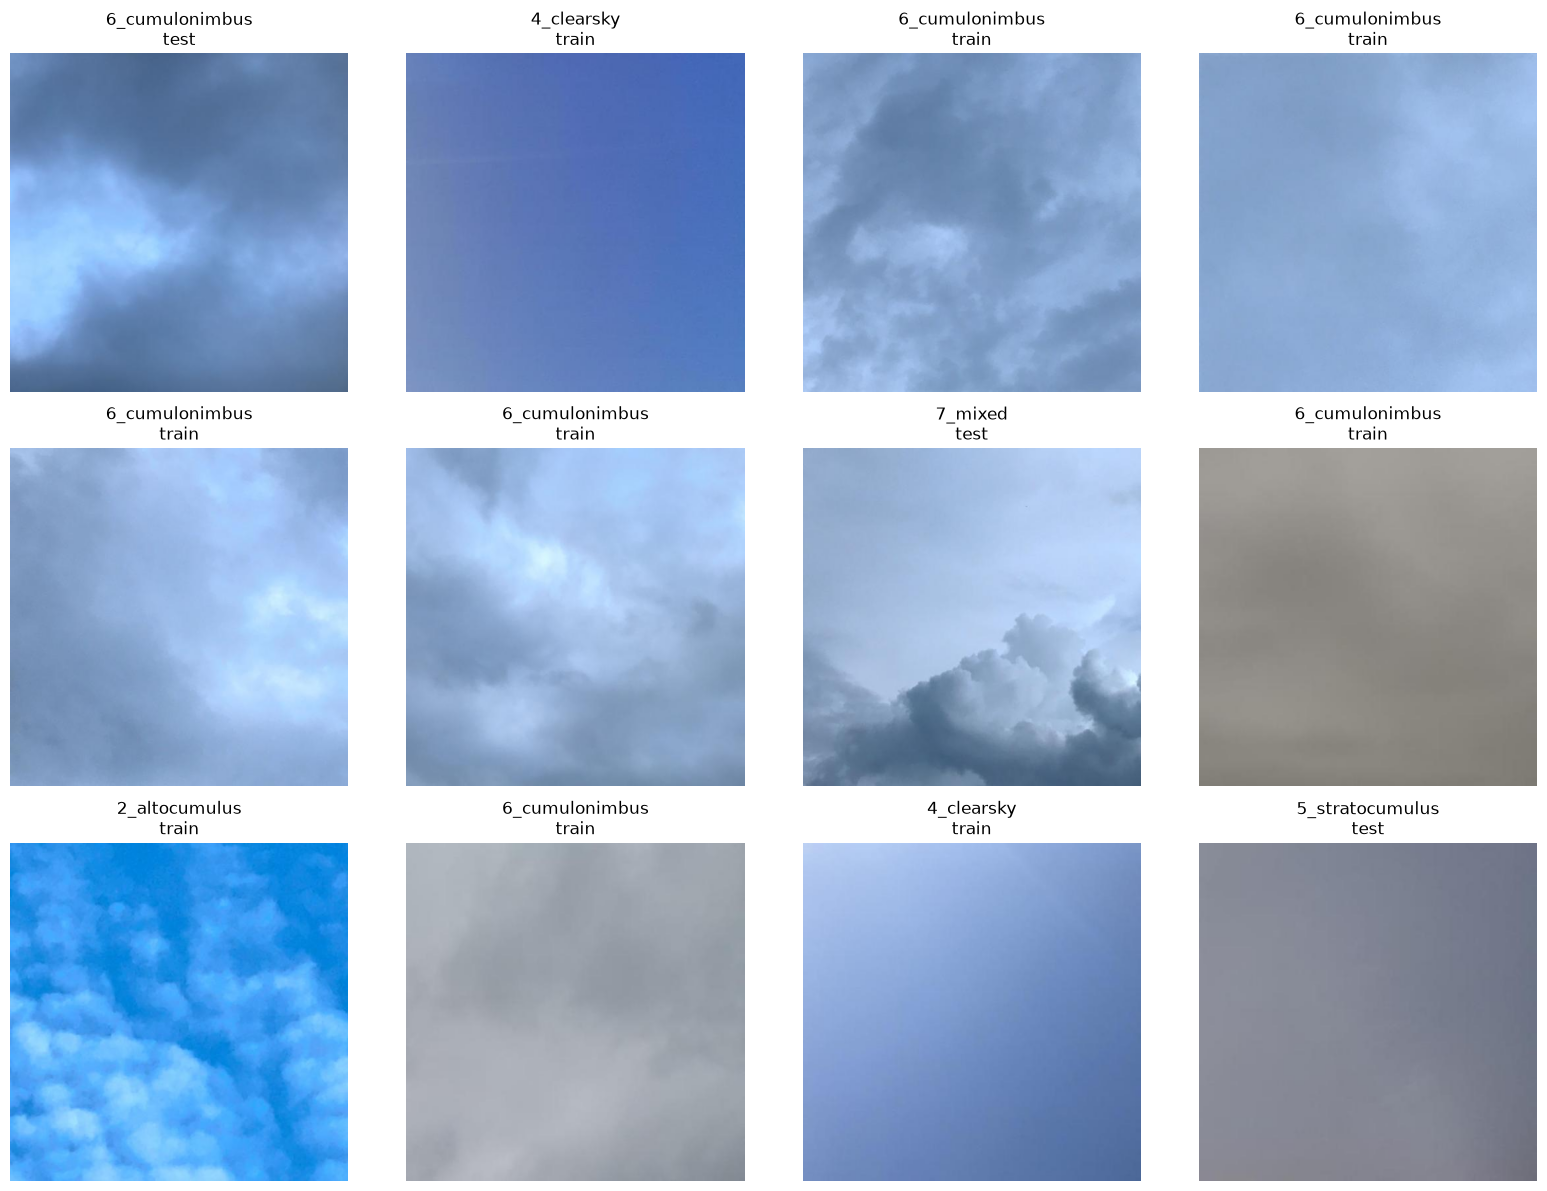

In [48]:
show_random_images(
    df,
    n=12
)

In [49]:
def show_one_image_per_class(
    dataframe,
    seed=42
):
    classes = sorted(
        dataframe["class_id"].unique()
    )

    plt.figure(
        figsize=(18, 10)
    )

    for i, class_id in enumerate(
        classes,
        start=1
    ):
        class_data = dataframe[
            dataframe["class_id"] == class_id
        ]

        if class_data.empty:
            continue

        sample = class_data.sample(
            1,
            random_state=seed
        ).iloc[0]

        image = Image.open(
            sample["absolute_path"]
        ).convert("RGB")

        plt.subplot(
            2,
            4,
            i
        )

        plt.imshow(image)

        plt.title(
            f"Class {class_id}\n"
            f"{sample['class_name']}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

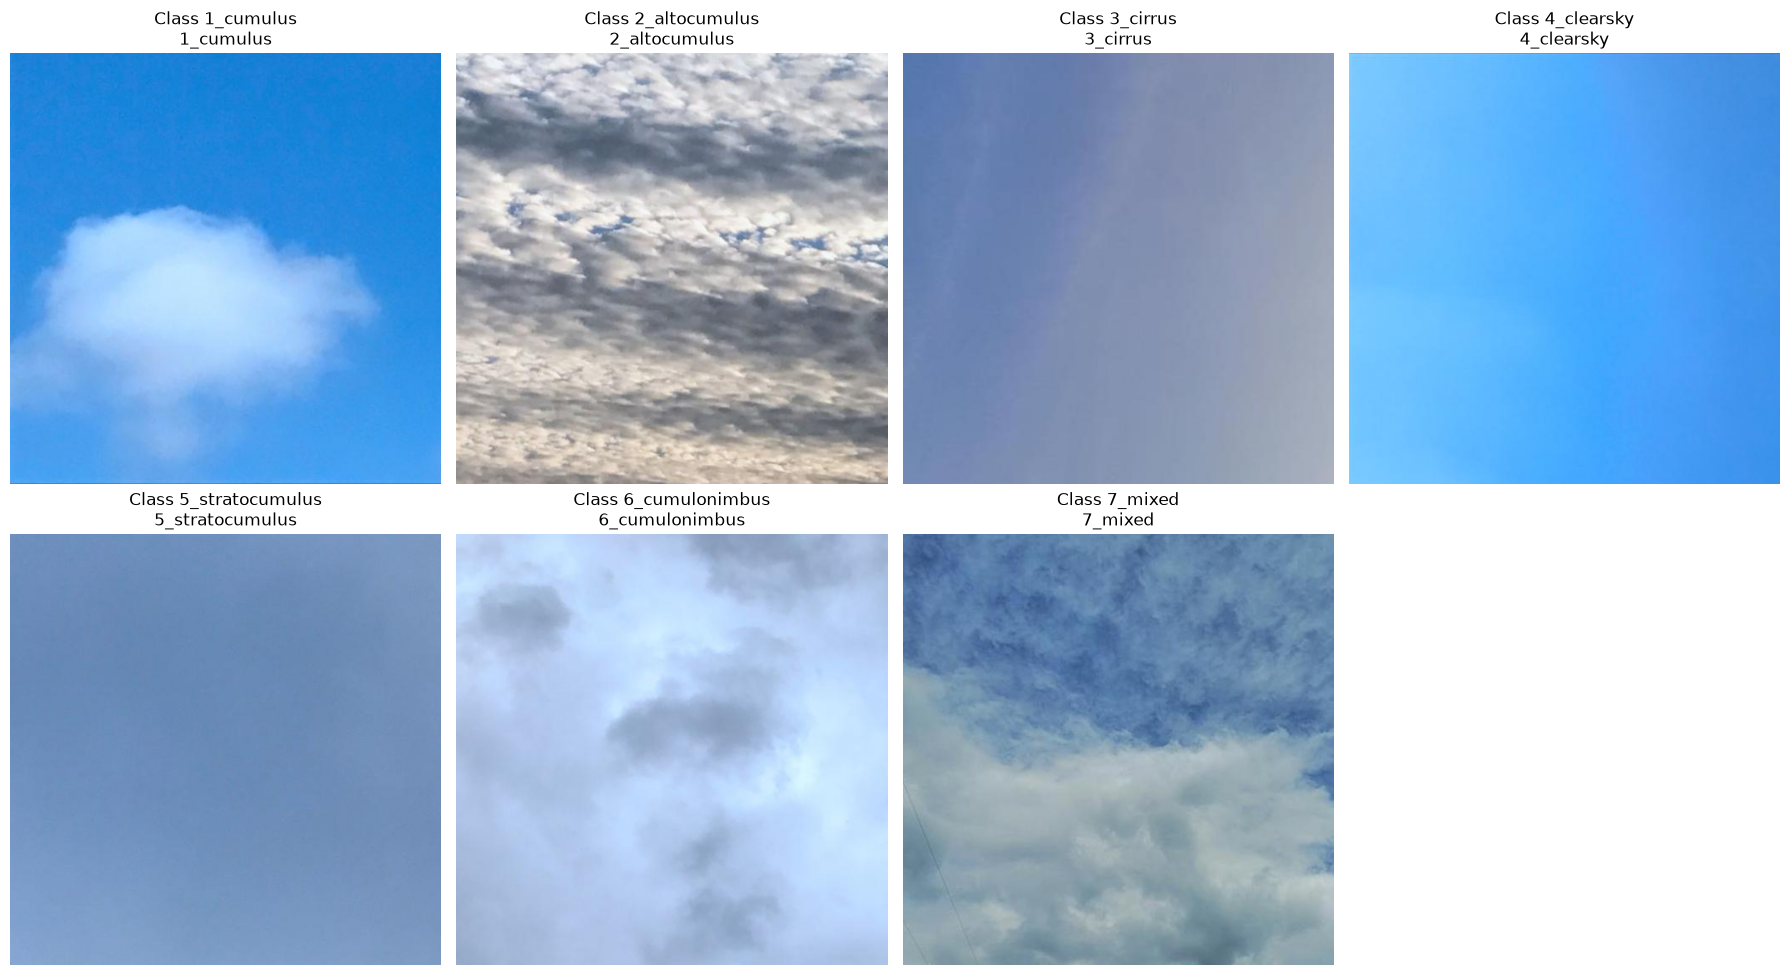

In [50]:
show_one_image_per_class(df)

In [51]:
def show_class_samples(
    dataframe,
    class_id,
    n=8,
    seed=42
):
    subset = dataframe[
        dataframe["class_id"].astype(str)
        == str(class_id)
    ]

    if subset.empty:
        print(
            f"Class {class_id} tidak ditemukan."
        )
        return

    sample = subset.sample(
        n=min(n, len(subset)),
        random_state=seed
    )

    cols = 4
    rows = int(
        np.ceil(len(sample) / cols)
    )

    plt.figure(
        figsize=(16, rows * 4)
    )

    for i, (_, row) in enumerate(
        sample.iterrows(),
        start=1
    ):
        image = Image.open(
            row["absolute_path"]
        ).convert("RGB")

        plt.subplot(
            rows,
            cols,
            i
        )

        plt.imshow(image)
        plt.title(row["filename"])
        plt.axis("off")

    class_name = CLASS_NAMES.get(
        str(class_id),
        str(class_id)
    )

    plt.suptitle(
        f"Class {class_id} — {class_name}",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

In [53]:
show_class_samples(df, "2")
show_class_samples(df, "3")
show_class_samples(df, "4")
show_class_samples(df, "5")
show_class_samples(df, "6")
show_class_samples(df, "7")

Class 2 tidak ditemukan.
Class 3 tidak ditemukan.
Class 4 tidak ditemukan.
Class 5 tidak ditemukan.
Class 6 tidak ditemukan.
Class 7 tidak ditemukan.


In [54]:
PIXEL_SAMPLE_PER_CLASS = 100

pixel_samples = []

for class_id in sorted(
    df["class_id"].unique()
):
    class_df = df[
        df["class_id"] == class_id
    ]

    n_samples = min(
        PIXEL_SAMPLE_PER_CLASS,
        len(class_df)
    )

    sampled = class_df.sample(
        n=n_samples,
        random_state=42
    )

    pixel_samples.append(sampled)

pixel_df = pd.concat(
    pixel_samples,
    ignore_index=True
)

print(
    "Jumlah citra untuk analisis piksel:",
    len(pixel_df)
)

Jumlah citra untuk analisis piksel: 700


In [55]:
def image_statistics(path):
    image = Image.open(path).convert("RGB")

    array = np.asarray(
        image,
        dtype=np.float32
    )

    mean_rgb = array.mean(
        axis=(0, 1)
    )

    std_rgb = array.std(
        axis=(0, 1)
    )

    brightness = array.mean()

    contrast = array.std()

    return {
        "mean_r": mean_rgb[0],
        "mean_g": mean_rgb[1],
        "mean_b": mean_rgb[2],
        "std_r": std_rgb[0],
        "std_g": std_rgb[1],
        "std_b": std_rgb[2],
        "brightness": brightness,
        "contrast": contrast,
    }

In [56]:
pixel_statistics = []

for _, row in tqdm(
    pixel_df.iterrows(),
    total=len(pixel_df),
    desc="Analisis statistik piksel"
):
    try:
        stats = image_statistics(
            row["absolute_path"]
        )

        stats.update({
            "class_id": row["class_id"],
            "class_name": row["class_name"],
            "split": row["split"],
            "filename": row["filename"],
        })

        pixel_statistics.append(stats)

    except Exception as e:
        print(
            "Error:",
            row["filename"],
            e
        )


pixel_stats_df = pd.DataFrame(
    pixel_statistics
)

display(
    pixel_stats_df.head()
)

Analisis statistik piksel:   0%|          | 0/700 [00:00<?, ?it/s]

,mean_r,mean_g,mean_b,std_r,std_g,std_b,brightness,contrast,class_id,class_name,split,filename
0,75.594971,158.049667,232.218307,51.908112,28.509375,13.178152,155.264694,72.911659,1_cumulus,1_cumulus,train,1_cumulus_000033.jpg
1,153.342712,155.421021,154.015900,46.713390,45.460365,42.080322,154.248688,44.802525,1_cumulus,1_cumulus,test,1_cumulus_000852.jpg
2,84.818069,142.059387,203.575790,52.983219,39.456249,29.362963,143.468124,63.964191,1_cumulus,1_cumulus,train,1_cumulus_000260.jpg
3,95.352371,153.093735,206.770691,78.860558,55.569138,38.481617,151.719208,75.257286,1_cumulus,1_cumulus,train,1_cumulus_000654.jpg
4,126.944542,161.206787,202.665771,44.374096,40.565987,35.589615,163.594299,50.838245,1_cumulus,1_cumulus,train,1_cumulus_000097.jpg


In [57]:
rgb_summary = (
    pixel_stats_df
    .groupby("class_name")
    [
        [
            "mean_r",
            "mean_g",
            "mean_b",
        ]
    ]
    .mean()
)

display(
    rgb_summary.round(2)
)

,mean_r,mean_g,mean_b
class_name,,,
1_cumulus,103.230003,149.240005,195.360001
2_altocumulus,131.860001,163.649994,198.169998
3_cirrus,104.260002,150.000000,199.380005
4_clearsky,70.349998,137.940002,206.649994
5_stratocumulus,154.550003,168.910004,187.449997
6_cumulonimbus,142.710007,159.800003,183.130005
7_mixed,129.029999,160.250000,195.610001


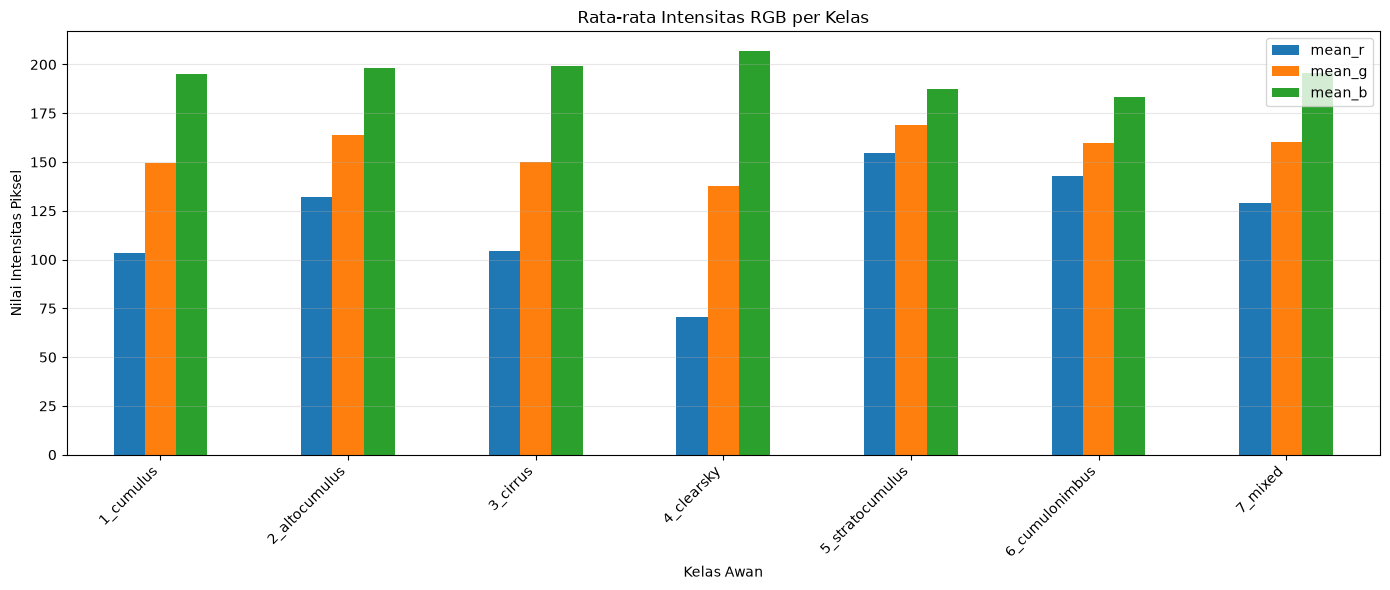

In [58]:
rgb_summary.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title(
    "Rata-rata Intensitas RGB per Kelas"
)

plt.xlabel(
    "Kelas Awan"
)

plt.ylabel(
    "Nilai Intensitas Piksel"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [59]:
brightness_summary = (
    pixel_stats_df
    .groupby("class_name")["brightness"]
    .agg(
        [
            "mean",
            "std",
            "min",
            "max",
        ]
    )
)

display(
    brightness_summary.round(2)
)

,mean,std,min,max
class_name,,,,
1_cumulus,149.259995,17.740000,91.510002,186.190002
2_altocumulus,164.550003,23.450001,99.379997,221.270004
3_cirrus,151.199997,20.629999,80.279999,192.330002
4_clearsky,138.289993,27.129999,53.330002,204.020004
5_stratocumulus,170.300003,19.950001,123.639999,230.919998
6_cumulonimbus,161.880005,19.790001,88.830002,206.419998
7_mixed,161.619995,18.459999,111.230003,199.369995


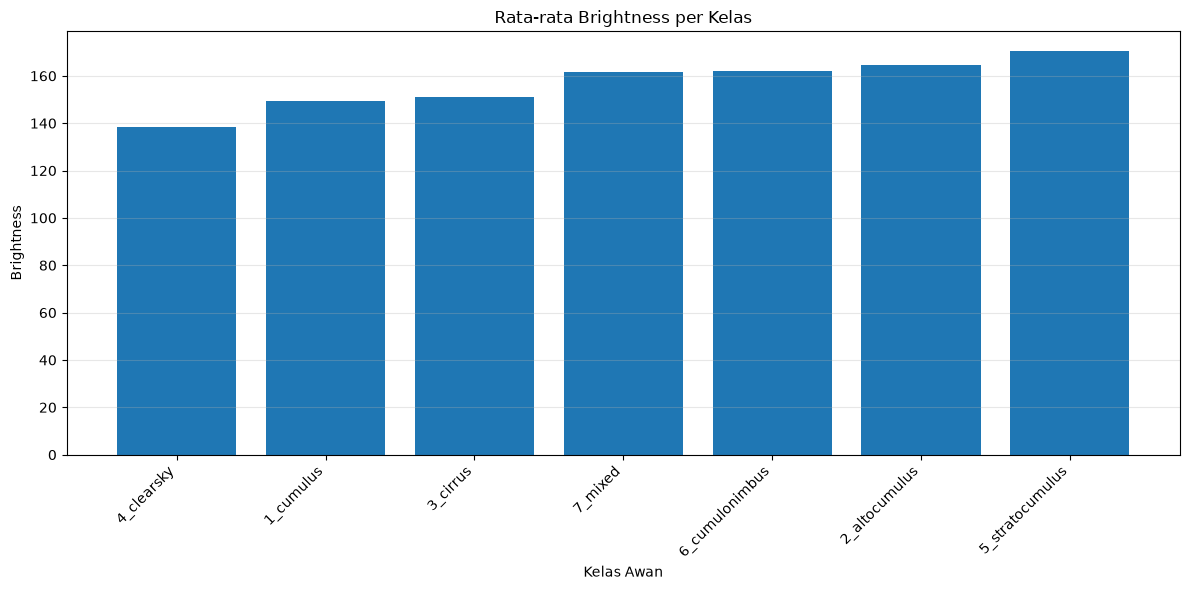

In [60]:
brightness_mean = (
    pixel_stats_df
    .groupby("class_name")["brightness"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12, 6))

plt.bar(
    brightness_mean.index,
    brightness_mean.values
)

plt.title(
    "Rata-rata Brightness per Kelas"
)

plt.xlabel(
    "Kelas Awan"
)

plt.ylabel(
    "Brightness"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [61]:
contrast_summary = (
    pixel_stats_df
    .groupby("class_name")["contrast"]
    .agg(
        [
            "mean",
            "std",
            "min",
            "max",
        ]
    )
)

display(
    contrast_summary.round(2)
)

,mean,std,min,max
class_name,,,,
1_cumulus,57.910000,17.410000,16.830000,91.839996
2_altocumulus,40.020000,18.270000,8.640000,85.470001
3_cirrus,46.990002,21.650000,14.150000,94.620003
4_clearsky,58.250000,20.629999,24.030001,103.230003
5_stratocumulus,19.750000,10.030000,5.680000,47.950001
6_cumulonimbus,27.150000,9.880000,5.320000,51.560001
7_mixed,42.020000,17.040001,9.200000,74.989998


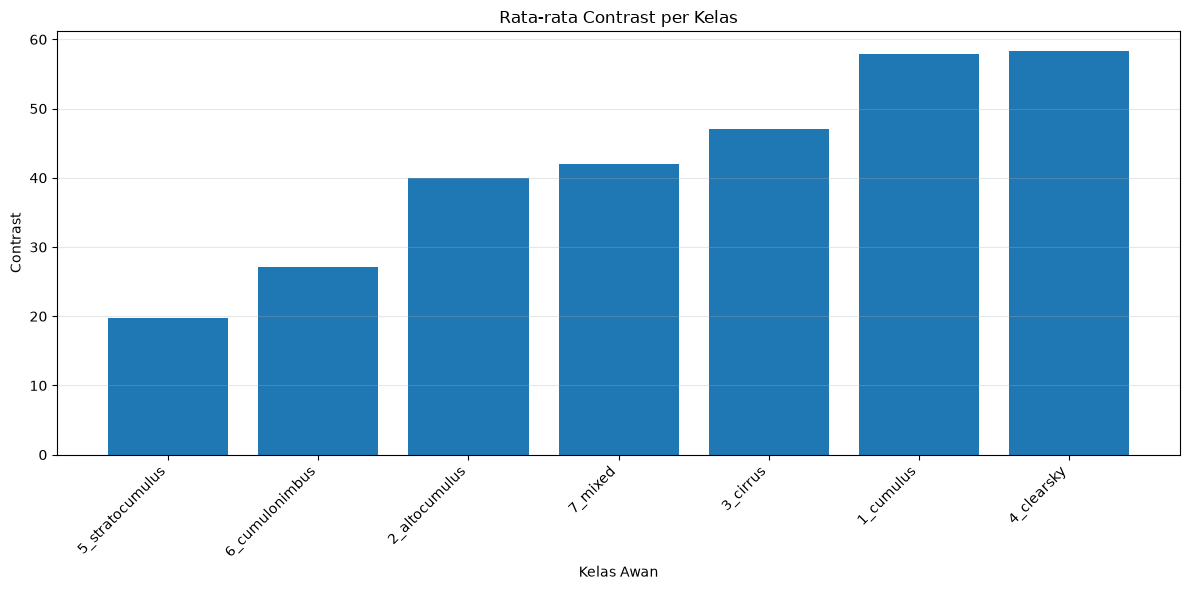

In [62]:
contrast_mean = (
    pixel_stats_df
    .groupby("class_name")["contrast"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12, 6))

plt.bar(
    contrast_mean.index,
    contrast_mean.values
)

plt.title(
    "Rata-rata Contrast per Kelas"
)

plt.xlabel(
    "Kelas Awan"
)

plt.ylabel(
    "Contrast"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

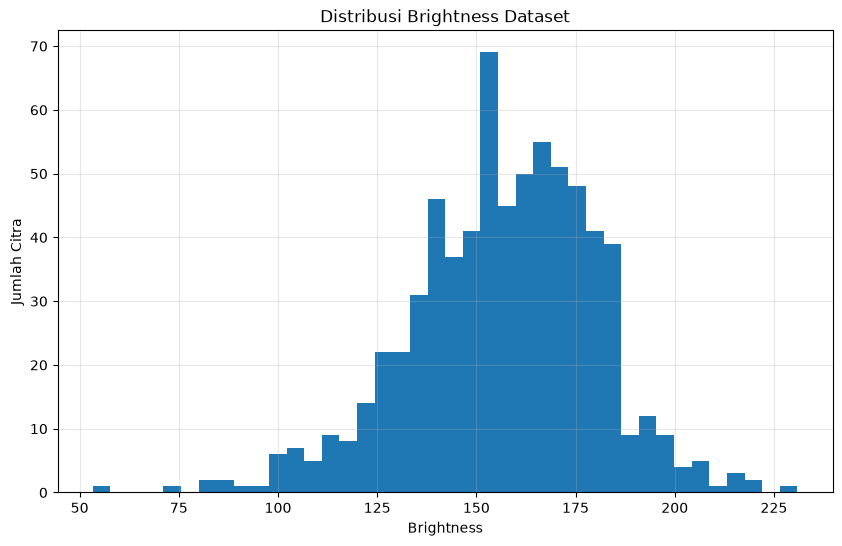

In [63]:
plt.figure(figsize=(10, 6))

plt.hist(
    pixel_stats_df["brightness"],
    bins=40
)

plt.title(
    "Distribusi Brightness Dataset"
)

plt.xlabel(
    "Brightness"
)

plt.ylabel(
    "Jumlah Citra"
)

plt.grid(alpha=0.3)

plt.show()

In [64]:
pixel_stats_df["r_minus_b"] = (
    pixel_stats_df["mean_r"]
    -
    pixel_stats_df["mean_b"]
)

In [65]:
rb_summary = (
    pixel_stats_df
    .groupby("class_name")["r_minus_b"]
    .agg(
        [
            "mean",
            "std",
            "min",
            "max",
        ]
    )
)

display(
    rb_summary.round(2)
)

,mean,std,min,max
class_name,,,,
1_cumulus,-92.129997,41.709999,-201.210007,-0.670000
2_altocumulus,-66.309998,49.639999,-197.539993,3.120000
3_cirrus,-95.129997,58.990002,-224.050003,-5.780000
4_clearsky,-136.289993,53.790001,-250.940002,-22.610001
5_stratocumulus,-32.900002,30.040001,-115.300003,7.120000
6_cumulonimbus,-40.419998,27.209999,-82.940002,7.890000
7_mixed,-66.580002,37.750000,-160.830002,9.340000


In [66]:
distribution_matrix = pd.pivot_table(
    df,
    index=[
        "class_id",
        "class_name",
    ],
    columns="split",
    values="filename",
    aggfunc="count",
    fill_value=0
)

display(
    distribution_matrix
)

,split,test,train
class_id,class_name,,
1_cumulus,1_cumulus,750,775
2_altocumulus,2_altocumulus,750,725
3_cirrus,3_cirrus,753,1153
4_clearsky,4_clearsky,1589,2150
5_stratocumulus,5_stratocumulus,1790,1846
6_cumulonimbus,6_cumulonimbus,2761,3003
7_mixed,7_mixed,607,348


In [67]:
class_percentage = (
    df["class_name"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

class_percentage_df = (
    class_percentage
    .rename_axis("class_name")
    .reset_index(name="percentage")
)

display(
    class_percentage_df
)

,class_name,percentage
0,6_cumulonimbus,30.34
1,4_clearsky,19.68
2,5_stratocumulus,19.14
3,3_cirrus,10.03
4,1_cumulus,8.03
5,2_altocumulus,7.76
6,7_mixed,5.03


In [68]:
total_images = len(df)

total_classes = (
    df["class_id"]
    .nunique()
)

total_corrupted = (
    len(corrupted_files)
)

total_unexpected_resolution = (
    len(unexpected_resolution)
)

total_exact_duplicates = (
    len(duplicate_hashes)
)

total_leakage = (
    len(leakage_df)
)

print("=" * 70)
print("HASIL ANALISIS DATASET GCD")
print("=" * 70)

print(
    f"Total citra                : "
    f"{total_images:,}"
)

print(
    f"Total kelas                : "
    f"{total_classes}"
)

print(
    f"Train                      : "
    f"{observed_train:,}"
)

print(
    f"Test                       : "
    f"{observed_test:,}"
)

print(
    f"File rusak                 : "
    f"{total_corrupted}"
)

print(
    f"Resolusi bukan 512x512     : "
    f"{total_unexpected_resolution}"
)

print(
    f"Exact duplicate files      : "
    f"{total_exact_duplicates}"
)

print(
    f"Train-test leakage         : "
    f"{total_leakage}"
)

print(
    f"Imbalance ratio            : "
    f"{imbalance_ratio:.2f}"
)

print("=" * 70)

HASIL ANALISIS DATASET GCD
Total citra                : 19,000
Total kelas                : 7
Train                      : 10,000
Test                       : 9,000
File rusak                 : 0
Resolusi bukan 512x512     : 0
Exact duplicate files      : 318
Train-test leakage         : 312
Imbalance ratio            : 6.04


In [71]:
checks = {
    "dataset_ditemukan":
        DATASET_ROOT.exists(),

    "dataset_tidak_kosong":
        total_images > 0,

    "jumlah_kelas_7":
        total_classes == 7,

    "tidak_ada_file_rusak":
        total_corrupted == 0,

    "resolusi_sesuai":
        total_unexpected_resolution == 0,

    "tidak_ada_train_test_leakage":
        total_leakage == 0,
}


quality_check = pd.DataFrame(
    {
        "Pemeriksaan": checks.keys(),
        "Status": [
            "PASS" if value else "CHECK"
            for value in checks.values()
        ],
    }
)

display(
    quality_check
)

,Pemeriksaan,Status
0,dataset_ditemukan,PASS
1,dataset_tidak_kosong,PASS
2,jumlah_kelas_7,PASS
3,tidak_ada_file_rusak,PASS
4,resolusi_sesuai,PASS
5,tidak_ada_train_test_leakage,CHECK


In [72]:
if all(checks.values()):

    print(
        "STATUS DATASET: SIAP UNTUK TAHAP BERIKUTNYA"
    )

    print(
        "\nDataset lolos pemeriksaan struktur, "
        "integritas file, resolusi, jumlah kelas, "
        "dan tidak ditemukan exact duplicate "
        "antara data train dan test."
    )

else:

    print(
        "STATUS DATASET: PERLU PEMERIKSAAN"
    )

    print(
        "\nTerdapat satu atau lebih pemeriksaan "
        "yang membutuhkan perhatian sebelum "
        "preprocessing dan training."
    )

STATUS DATASET: PERLU PEMERIKSAAN

Terdapat satu atau lebih pemeriksaan yang membutuhkan perhatian sebelum preprocessing dan training.


# Kesimpulan Analisis Dataset

Tahap analisis dataset dilakukan untuk memastikan bahwa data GCD
memiliki struktur dan kualitas yang sesuai sebelum digunakan dalam
pelatihan model klasifikasi citra awan.

Aspek yang diperiksa meliputi jumlah citra, jumlah kelas, distribusi
data train dan test, format citra, resolusi, mode warna, integritas
file, distribusi kelas, kemungkinan duplikasi data, serta potensi
data leakage antara data training dan testing.

Analisis visual juga dilakukan terhadap sampel setiap kelas untuk
memastikan keterkaitan antara struktur direktori dan label kelas.
Selain itu, statistik brightness, contrast, serta intensitas kanal
RGB dianalisis untuk memperoleh gambaran mengenai variasi karakteristik
visual pada masing-masing kategori awan.

Hasil analisis pada notebook ini menjadi dasar untuk menentukan
strategi preprocessing dan augmentasi pada tahap berikutnya tanpa
melakukan perubahan terhadap dataset asli.

In [88]:
# ============================================================
# PEMERIKSAAN DUPLICATE DENGAN LABEL BERBEDA
# ============================================================

if not duplicate_hashes.empty:

    label_conflict_summary = (
        duplicate_hashes
        .groupby("sha256")
        .agg(
            jumlah_file=("filename", "count"),
            jumlah_kelas=("class_name", "nunique"),
            kelas=(
                "class_name",
                lambda x: sorted(set(x))
            ),
            split=(
                "split",
                lambda x: sorted(set(x))
            )
        )
        .reset_index()
    )

    conflicting_labels = (
        label_conflict_summary[
            label_conflict_summary["jumlah_kelas"] > 1
        ]
    )

    print("=" * 65)
    print("PEMERIKSAAN KONFLIK LABEL")
    print("=" * 65)

    print(
        f"Total kelompok duplicate : "
        f"{len(label_conflict_summary):,}"
    )

    print(
        f"Duplicate beda label     : "
        f"{len(conflicting_labels):,}"
    )

    print("=" * 65)

    if len(conflicting_labels) == 0:
        print(
            "PASS - Tidak ditemukan citra identik "
            "dengan label kelas berbeda."
        )
    else:
        print(
            "CHECK - Ditemukan citra identik "
            "dengan label kelas berbeda."
        )

        display(conflicting_labels)

else:
    print("Tidak ditemukan exact duplicate.")

PEMERIKSAAN KONFLIK LABEL
Total kelompok duplicate : 159
Duplicate beda label     : 0
PASS - Tidak ditemukan citra identik dengan label kelas berbeda.


In [89]:
# ============================================================
# RINGKASAN FINAL ANALISIS DATASET
# ============================================================

print("=" * 72)
print("RINGKASAN FINAL - 02 ANALISIS DATASET GCD")
print("=" * 72)

print(f"Total citra                  : {len(df):,}")
print(f"Jumlah kelas                 : {df['class_id'].nunique()}")
print(f"Train                        : {(df['split'] == 'train').sum():,}")
print(f"Test                         : {(df['split'] == 'test').sum():,}")

print("-" * 72)

print(f"File rusak                   : {len(corrupted_files):,}")
print(f"Resolusi selain 512x512      : {len(unexpected_resolution):,}")

print("-" * 72)

print(f"Exact duplicate files        : {len(duplicate_hashes):,}")
print(f"Train-test leakage files     : {len(leakage_df):,}")
print(f"Train-test leakage groups    : {leakage_df['sha256'].nunique():,}")

print("-" * 72)

print("Distribusi duplicate:")
print("  Train-test leakage         : 312 file / 156 group")
print("  Duplicate within test      : 4 file / 2 group")
print("  Duplicate within train     : 2 file / 1 group")

print("-" * 72)

print("Leakage berdasarkan kelas:")
print("  4_clearsky                 : 155 pasangan")
print("  7_mixed                    : 1 pasangan")

print("-" * 72)

print("Class imbalance:")
print("  Kelas terbesar             : 6_cumulonimbus (5,764)")
print("  Kelas terkecil             : 7_mixed (955)")
print(f"  Imbalance ratio            : {imbalance_ratio:.2f}")

print("-" * 72)

if "conflicting_labels" in globals():

    print(
        f"Duplicate beda label         : "
        f"{len(conflicting_labels):,}"
    )

print("=" * 72)

RINGKASAN FINAL - 02 ANALISIS DATASET GCD
Total citra                  : 19,000
Jumlah kelas                 : 7
Train                        : 10,000
Test                         : 9,000
------------------------------------------------------------------------
File rusak                   : 0
Resolusi selain 512x512      : 0
------------------------------------------------------------------------
Exact duplicate files        : 318
Train-test leakage files     : 312
Train-test leakage groups    : 156
------------------------------------------------------------------------
Distribusi duplicate:
  Train-test leakage         : 312 file / 156 group
  Duplicate within test      : 4 file / 2 group
  Duplicate within train     : 2 file / 1 group
------------------------------------------------------------------------
Leakage berdasarkan kelas:
  4_clearsky                 : 155 pasangan
  7_mixed                    : 1 pasangan
------------------------------------------------------------------